# The G/G/1 Queue

A **G/G/1 queue** has one server, one line, and first come, first served. The name is
**Kendall's notation**: **G**eneral (any) distribution for the time between arrivals,
**G**eneral distribution for the service times, and **1** server.

| Class | Arrivals | Service |
|---|---|---|
| `GG1(interarrival_dist, service_dist)` | any distribution | any distribution |
| `MG1(arrival_rate, service_dist)` | Poisson (exponential gaps) | any distribution |
| `GM1(interarrival_dist, service_rate)` | any distribution | exponential |

`X[t]` is the **number of customers in the system** at time `t` -- the one being served
plus everybody still in line -- exactly what the `M/M/...` queues in `markov_chains.py`
report. The count starts at 0, steps up at each arrival, and steps down at each departure.

Those departures are the only hard part, and **Lindley's recursion** settles them:
`W[n+1] = max(W[n] + S[n] - A[n+1], 0)`, i.e. a customer waits for whatever is left of the
customer ahead of them, or not at all if the server went idle in between. Add the wait and
the service to the arrival time and you have the departure. Those waits stay on the drawn
path, as `waiting_times`.

In [23]:
from symbulate import *

## `GG1` -- any arrivals, any service

Hand it two distributions: one for the gaps between arrivals, one for the service times.
`utilization` is the fraction of time the server is busy -- the queue settles down when it
is below 1, and grows without bound when it is not.

In [24]:
# Customers arrive on average 1 apart; each service takes between 0 and 1.
queue = GG1(interarrival_dist=Exponential(rate=1), service_dist=Uniform(a=0, b=1))
print("utilization:", queue.utilization)

path = queue.sim(1)
[path[t] for t in [0, 1, 2, 5, 10]]  # how many were in the system at each time

utilization: 0.5


[Index Result
 0     0,
 Index Result
 0     0,
 Index Result
 0     0,
 Index Result
 0     1,
 Index Result
 0     2]

Each draw is a step function of continuous time, so simulate and plot sample paths as for
any other random process.

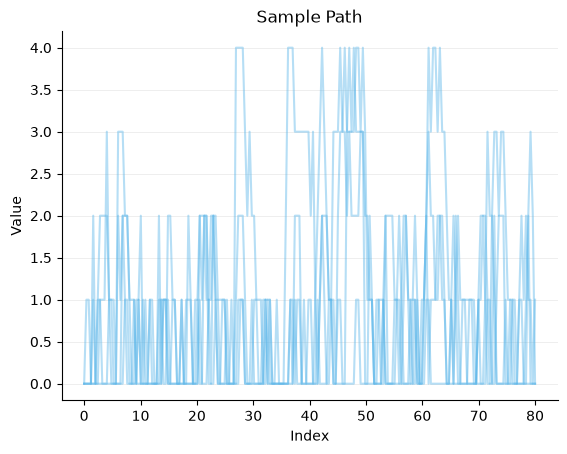

In [25]:
queue.sim(4).plot(tmin=0, tmax=80)

## `MG1` -- Poisson arrivals, any service

Give an arrival *rate* instead of a distribution and the gaps between arrivals are
Exponential, so customers arrive as a Poisson process.

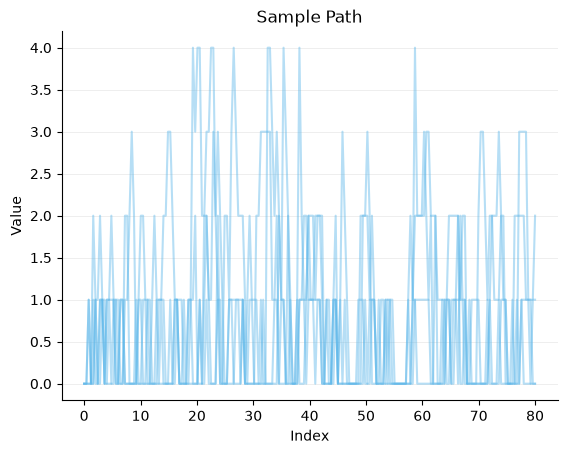

In [26]:
mg1 = MG1(arrival_rate=1, service_dist=Gamma(shape=2, rate=4))
mg1.sim(4).plot(tmin=0, tmax=80)

## `GM1` -- any arrivals, exponential service

The other way round: give a service *rate*, and describe the arrivals however you like.

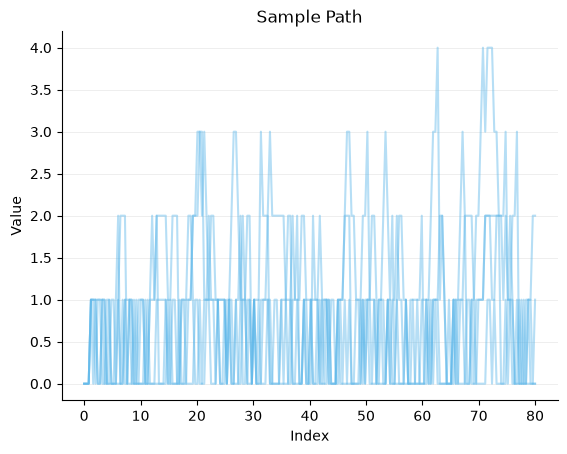

In [27]:
gm1 = GM1(interarrival_dist=Gamma(shape=8, rate=8), service_rate=2)
gm1.sim(4).plot(tmin=0, tmax=80)

## The special case: M/M/1

Exponential gaps between arrivals *are* Poisson arrivals -- that is what the **M** (for
memoryless) stands for in Kendall's notation. So making both distributions exponential gives
the `M/M/1` queue: Poisson arrivals at rate 1 below, and exponential service at rate 2. Any
of the three classes can spell it, since each one is exponential on the side it fixes.

The `MM1` class in `markov_chains.py` models this same queue and reports the same thing, as a
birth-death Markov chain. That shortcut is only available because the service times are
exponential; `GG1` reaches the same count without needing them to be.

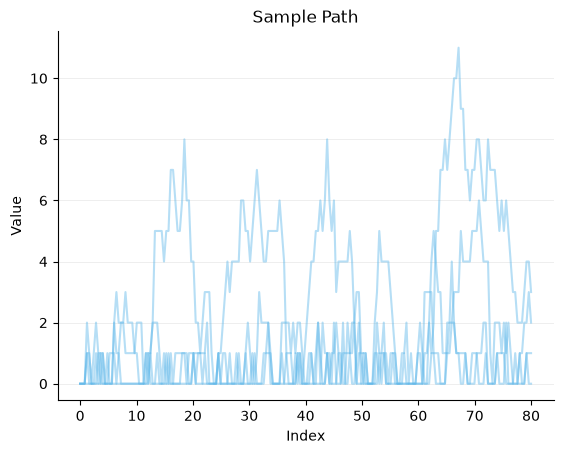

In [28]:
mm1 = GG1(Exponential(rate=1), Exponential(rate=2))
# The same queue: MG1(arrival_rate=1, service_dist=Exponential(rate=2))
#                 GM1(interarrival_dist=Exponential(rate=1), service_rate=2)
mm1.sim(4).plot(tmin=0, tmax=80)

## The number in the system at a fixed time

Index the queue at a time to get an ordinary random variable, then simulate, plot, and
summarize it as usual. For this M/M/1 queue the long-run count is Geometric with mean
`rho / (1 - rho)` = 1, and the spike at 0 is how often an arrival finds the system empty.

Simulating... [██████████████████████████████] 1000/1000 (100%)


1.036

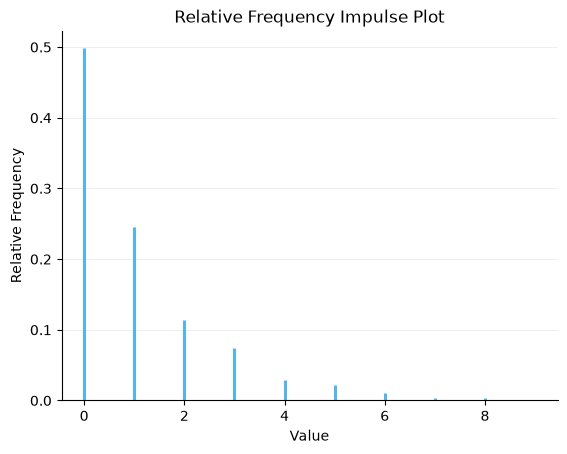

In [29]:
number = mm1[50].sim(1000)
number.plot()
number.mean()

## The waiting times underneath

The waits Lindley's recursion produced are still on the path, along with each customer's
service time, arrival and departure times, and `sojourn_times` (waiting plus service). Any
of them becomes a random variable with `.apply()`.

In [30]:
path = mm1.draw()
print("first five waits:", [round(path.waiting_times[n], 2) for n in range(5)])

wait = mm1.apply(lambda path: path.waiting_times[50])
wait.sim(1000).mean()  # theory says rho / (mu - lambda) = 0.5

first five waits: [0.0, 0.0, 0.36, 0.0, 0.17]


0.5011167127612447